<h1 style="text-align: center;">Correction et Colorisation d'images</h1>

In [2]:
!pip install pycocotools opencv-python pillow tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [23]:
# Importation des différentes librairies utiles pour le notebook

# Sickit-learn met régulièrement à jour des versions et
# indique des futurs warnings. Ces lignes permettent de ne pas les afficher.
import warnings  # Permet de gérer les avertissements
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd  # Manipulation de données en format tabulaire
from scipy.stats import randint  # Pour les distributions aléatoires
import numpy as np  # Calcul numérique
from numpy import mean, std  # Statistiques de base
import os  # Interaction avec le système d'exploitation
from os import listdir  # Liste les fichiers dans un répertoire
from os.path import isfile, join  # Fonctions pour gérer les chemins de fichiers
import sys  # Manipulation du système
import random  # Génération de nombres aléatoires
import cv2  # Librairie pour la vision par ordinateur
import zipfile  # Manipulation des archives ZIP
import requests
from tqdm import tqdm
from pycocotools.coco import COCO
from PIL import Image

# Librairie d'affichage
import matplotlib.pyplot as plt  # Visualisation de données
from PIL import Image, ImageDraw  # Manipulation d'images avec Pillow

# Scikit-learn pour l'apprentissage automatique
from sklearn.decomposition import PCA  # Analyse en composantes principales(ACP)

# TensorFlow et Keras pour le deep learning
import tensorflow as tf  # Framework principal pour l'apprentissage profond
import keras  # API de haut niveau pour TensorFlow
from keras import layers  # Modules de construction de modèles Keras
from keras import models  # Définition et manipulation des modèles
from keras import optimizers  # Optimisateurs pour les modèles Keras
from keras.optimizers import Adam  # Optimiseur Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator  #Générateur

# Utilitaires Keras pour le traitement d'images
from keras.utils import img_to_array, load_img  # Conversion images en tableaux
from keras.callbacks import (ModelCheckpoint,
                             EarlyStopping)  # Gestion des checkpoints
from keras import backend as K  # Backend Keras pour opérations de bas niveau
from keras.models import Model, load_model  # Définition/chargement des modèles
from keras.layers import LeakyReLU  # Activation LeakyReLU
from keras.preprocessing import image  # Prétraitement des images

# Couches Keras pour les modèles convolutifs et autres
from keras.layers import (Input, Conv2D, Flatten, Dense, Conv2DTranspose,
                          Reshape, Activation,
                          BatchNormalization,
                          Dropout)  # Couches pour CNN et autoencoders
from keras.layers import (InputLayer, MaxPooling2D,
                          UpSampling2D)  # Couches supplémentaires pour les CNN



# Récuperer des images à partir de cocodataset

In [24]:
ann_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

if not os.path.exists("annotations"):
    !wget -q {ann_url} -O annotations.zip
    with zipfile.ZipFile("annotations.zip", 'r') as zip_ref:
        zip_ref.extractall(".")

In [25]:
categories = ["dog", "cat", "elephant"]
coco = COCO("annotations/instances_train2017.json")

cat_ids = coco.getCatIds(catNms=categories)

img_ids = set()

for cat_id in cat_ids:
    ids = coco.getImgIds(catIds=[cat_id])
    img_ids.update(ids)

img_ids = list(img_ids)

print("Images trouvées :", len(img_ids))

loading annotations into memory...
Done (t=7.58s)
creating index...
index created!
Images trouvées : 10423


In [17]:
def valid_bbox(bbox, min_size=64):
    x, y, w, h = bbox
    return w > min_size and h > min_size and (w/h < 2 and h/w < 2)

In [26]:
output_dir = "COCO_animals/train"
os.makedirs(output_dir, exist_ok=True)

def process_image(img_info, coco, size=(128,128)):
    url = img_info["coco_url"]
    img_id = img_info["id"]

    try:
        img_data = requests.get(url, timeout=10).content
        img_array = np.frombuffer(img_data, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        if img is None:
            return

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:
            if not valid_bbox(ann["bbox"]):
                continue

            x, y, w, h = map(int, ann["bbox"])
            crop = img[y:y+h, x:x+w]

            if crop.size == 0:
                continue

            crop = cv2.resize(crop, size)
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

            filename = f"{img_id}.png"
            Image.fromarray(crop).save(os.path.join(output_dir, filename))
            break 

    except:
        pass

In [48]:
import shutil

output_dir = "COCO_animals/train"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(output_dir, exist_ok=True)

max_images = 2000 

for img_id in tqdm(img_ids[:max_images]):
    img_info = coco.loadImgs(img_id)[0]
    process_image(img_info, coco)

100%|███████████████████████████████████████| 2000/2000 [33:36<00:00,  1.01s/it]


Nombre d'images : 1841
Shape : (128, 128, 3)


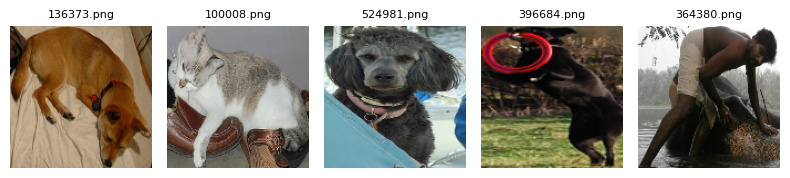

In [61]:
src_dir = "COCO_animals"
image_dir = "COCO_animals/train"
files = [f for f in os.listdir(image_dir) if f.endswith(".png")]

print("Nombre d'images :", len(files))

img = Image.open(os.path.join(image_dir, files[0]))
print("Shape :", img.size[::-1] + (3,))

random_files = random.sample(files, 5)

plt.figure(figsize=(8, 2))
for i, fname in enumerate(random_files):
    img_path = os.path.join(image_dir, fname)
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(fname, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [62]:
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory="COCO_animals",
    classes=['train'],
    target_size=(128,128),
    batch_size=512,
    shuffle=True,
    class_mode='input'
)

Found 1841 images belonging to 1 classes.


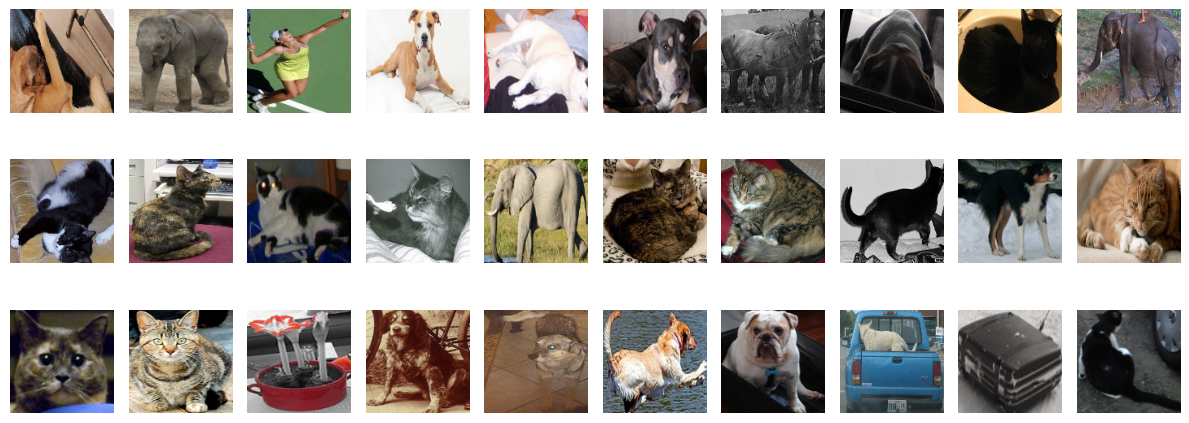

In [63]:
data_batch = next(data_flow)

images = data_batch[0]  # (batch_size, 128, 128, 3)

# combien d'images afficher
n = 30  

plt.figure(figsize=(12, 5))
for i in range(n):
    plt.subplot(3, 10, i + 1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Récuperer des modèles entraînés au préalable. 

In [64]:
# Définition du répertoire cible
model_dir = "./aeplus_models/"

# Création du répertoire s'il n'existe pas
os.makedirs(model_dir, exist_ok=True)

zip_file = "aeplus_models.zip"

!wget https://www.lirmm.fr/~poncelet/Ressources/aeplus_models.zip


# Extraction du fichier ZIP
with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(model_dir)

# Suppression du fichier ZIP après extraction pour économiser de l'espace
os.remove(zip_file)

--2026-05-01 19:09:16--  https://www.lirmm.fr/~poncelet/Ressources/aeplus_models.zip
Résolution de www.lirmm.fr (www.lirmm.fr)… 193.49.104.251
Connexion à www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443… connecté.
requête HTTP transmise, en attente de la réponse… 200 OK
Taille : 107830545 (103M) [application/zip]
Enregistre : ‘aeplus_models.zip’

aeplus_models.zip   100%[===================>] 102,83M  1,92MB/s    ds 56s     

2026-05-01 19:10:13 (1,83 MB/s) - ‘aeplus_models.zip’ enregistré [107830545/107830545]



# Autoencodeur

In [65]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 32             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur
epochs = 150

In [66]:
def build_encoder(input_dim, output_dim):
    tf.keras.backend.clear_session()

    encoder_input = Input(shape=input_dim, name='encoder_input')
    x = encoder_input

    x = Conv2D(32, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_1')(x)
    x = LeakyReLU(name='encoder_act_1')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_2')(x)
    x = LeakyReLU(name='encoder_act_2')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_3')(x)
    x = LeakyReLU(name='encoder_act_3')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_4')(x)
    x = LeakyReLU(name='encoder_act_4')(x)

    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = Flatten()(x)
    encoder_output = Dense(output_dim, name='encoder_output')(x)

    encoder = Model(encoder_input, encoder_output, name='encoder')
    return encoder_input, encoder_output, shape_before_flattening, encoder

In [67]:
# Création de l'encodeur avec les dimensions d'entrée et de sortie spécifiées
encoder_input, encoder_output, shape_before_flattening, encoder = build_encoder(
    input_dim=image_size,
    output_dim=latent_dim
)

# Affichage du résumé de l'encodeur
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,648 (3.48 MB)

 Trainable params: 912,648 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
def build_decoder(input_dim, shape_before_flattening):
    # Entrée du décodeur (vecteur latent)
    decoder_input = Input(shape=(input_dim,), name='decoder_input')

    # Projeter dans un tenseur de même forme qu'avant le Flatten de l'encodeur
    x = Dense(np.prod(shape_before_flattening))(decoder_input)
    x = Reshape(shape_before_flattening)(x)

    # Couches de déconvolution (effet miroir de l'encodeur)
    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_1')(x)
    x = LeakyReLU(name='decoder_act_1')(x)

    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_2')(x)
    x = LeakyReLU(name='decoder_act_2')(x)

    x = Conv2DTranspose(32, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_3')(x)
    x = LeakyReLU(name='decoder_act_3')(x)

    x = Conv2DTranspose(3, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_4')(x)
    decoder_output = Activation('sigmoid', name='decoder_output')(x)

    decoder = Model(decoder_input, decoder_output, name='decoder')
    return decoder_input, decoder_output, decoder

In [69]:
# Création du décodeur en utilisant la dimension de l'espace latent
# et le shape  avant le flattening
decoder_input, decoder_output, decoder = build_decoder(
    input_dim=latent_dim,
    shape_before_flattening=shape_before_flattening
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │       823,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1                  │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2                  │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_3                  │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_3 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_4                  │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Activation)     │ (None, 128, 128, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,483 (3.50 MB)

 Trainable params: 916,483 (3.50 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# L'entrée du modèle autoencodeur est celle de l'encodeur
autoencoder_input = encoder_input

# La sortie est obtenue en appliquant le décodeur à la sortie de l'encodeur
autoencoder_output = decoder(encoder_output)

# Création du modèle autoencodeur complet (encodeur + décodeur)
autoencoder = Model(autoencoder_input, autoencoder_output, name='autoencoder')

# Affichage de la structure du modèle
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       916,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829,131 (6.98 MB)

 Trainable params: 1,829,131 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
def train_autoencoder_from_generator(model, train_gen, val_gen,
                                     model_path, epochs=100, patience=5):
    """
    Entraîne un autoencodeur avec des générateurs Keras.

    Args:
        model         : modèle Keras compilé
        train_gen     : générateur d'entraînement
        val_gen       : générateur de validation
        model_path    : chemin de sauvegarde du meilleur modèle
        epochs        : nombre maximal d’époques
        patience      : patience pour EarlyStopping

    Returns:
        Le modèle avec les meilleurs poids restaurés.
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=model_path,
                        monitor='val_loss',
                        save_best_only=True,
                        save_weights_only=False,
                        verbose=1)
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return model

In [ ]:
# Définition des hyperparamètres
model_name = "coco_ae_best.keras"
model_path = os.path.join(model_dir, model_name)

# Compilation du modèle autoencodeur
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Générateur principal avec normalisation  et séparation train/validation
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur pour les données d'entraînement
train_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['train'],  # le sous-dossier contenant toutes les images
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input',
    subset='training'
)

# Générateur pour les données de validation
val_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['train'],
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=False,
    seed=42,
    class_mode='input',
    subset='validation'
)


# Entraînement du modèle autoencodeur
autoencoder = train_autoencoder_from_generator(
    model=autoencoder,
    train_gen=train_flow,
    val_gen=val_flow,
    model_path=model_path,
    epochs=epochs,
    patience=5
)

Found 1473 images belonging to 1 classes.
Found 368 images belonging to 1 classes.
Epoch 1/150


E0000 00:00:1777655416.208667   46761 meta_optimizer.cc:966] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/autoencoder_1/encoder_act_2_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/autoencoder_1/encoder_conv_2_1/BiasAdd'.


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.6822
Epoch 1: val_loss improved from None to 0.62863, saving model to ./aeplus_models/coco_ae_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.6652 - val_loss: 0.6286
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.6095
Epoch 2: val_loss improved from 0.62863 to 0.58048, saving model to ./aeplus_models/coco_ae_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.5980 - val_loss: 0.5805
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.5779
Epoch 3: val_loss improved from 0.58048 to 0.56711, saving model to ./aeplus_models/coco_ae_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.5745 - val_loss: 0.5671
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.5682
Epoch 4: val_loss improved from 0.56711 to 0.55879, saving model to ./aeplus_models/coco_ae_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.5652 - val_loss: 0.5588
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
def show_images(autoencoder, images=None):
    """
    Fonction pour afficher les images originales et leurs reconstructions générées par l'autoencodeur.

    Si aucun lot d'images n'est fourni, la fonction récupère un lot d'images depuis le générateur de données.

    Arguments :
    - autoencoder : L'autoencodeur entraîné, utilisé pour générer des reconstructions des images.
    - images (optionnel) : Un tableau d'images à afficher. Si non spécifié, un lot d'images est récupéré du générateur de données.

    Sortie :
    - Affichage des images originales et leurs reconstructions générées par l'autoencodeur.
    """

    if images is None:
        example_batch = next(data_flow)
        example_batch = example_batch[0]
        images = example_batch[:10]

    n_to_show = images.shape[0]

    # Génération des reconstructions des images
    reconst_images = autoencoder.predict(images)

    # Création de la figure pour l'affichage
    fig = plt.figure(figsize=(15, 3))
    fig.subplots_adjust(hspace=0.4, wspace=0.4)

    # Affichage des images originales
    for i in range(n_to_show):
        img = images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+1)
        sub.axis('off')
        sub.imshow(img)

    # Affichage des images reconstruites
    for i in range(n_to_show):
        img = reconst_images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+n_to_show+1)
        sub.axis('off')
        sub.imshow(img)

In [ ]:
# Chemin vers le modèle entraîné
model_path = os.path.join(model_dir, "coco_ae_best.keras")

# Chargement du modèle
autoencoder = load_model(model_path)

# Récupère le premier lot d'images du générateur de données
example_batch = next(data_flow)

# Sélectionne uniquement les images du batch (le premier élément a les images)
example_batch = example_batch[0]

# Prend les 10 premières images du lot pour les afficher
example_images = example_batch[:10]

# Affiche les images originales et reconstruites par l'autoencodeur
show_images(autoencoder, example_images)